# Melt Budget Data Loading
**Notebook 1 of 2** — run before `sankey_figures.ipynb`.

Loads, area-integrates, and saves CMIP6 and CESM2-LE ice and snow mass budget variables as `.nc` files to `save_path`. Processes one CMIP6 model at a time (set `models` below). The saved files are read directly by `sankey_figures.ipynb`.

In [1]:
# Install these packages once per session on the cryohub.
# All packages are used in the CMIP6 and CESM loading code: files/load.py
# Skip if these packages are already installed in your environment

# ── Core climate/geospatial dependencies ──────────────────────────────────────
%pip install -q regionmask       # regional masking for geospatial data
%pip install -q bottleneck       # speeds up xarray reduce operations (rolling mean, etc.)
%pip install -q xesmf            # regridding for Earth System Model output
%pip install -q cf_xarray        # CF convention accessor for xarray datasets

# ── ESGF data access ──────────────────────────────────────────────────────────
%pip install -q esgf-pyclient    # search client for the Earth System Grid Federation
%pip install -q intake-esgf      # intake driver for ESGF catalogs

# ── Version-pinned installs (workarounds) ─────────────────────────────────────
# importlib_metadata<8 fixes an import error with esmpy
# may no longer be needed    
#%pip install -q "importlib_metadata<8"

# globus-sdk must stay below v4 until intake-esgf adds compatibility
%pip install -q "globus-sdk<4"

# pydantic upgrade needed for intake-esm compatibility
%pip install -q --upgrade intake-esm pydantic

# numpy pinned to <=2.3 due to numba incompatibility
%pip install -q "numpy<=2.3"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xmip 0.7.2 requires xarrayutils, which is not installed.
xmip 0.7.2 requires xgcm<0.7.0, which is not installed.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-ai 2.31.7 requires faiss-cpu!=1.8.0.post0,<2.0.0,>=1.8.0, which is 

**Restart the kernel after the installs above before running any further cells.**

In [1]:
import os
import sys
import logging
from io import StringIO
import numpy as np
import pandas as pd
import xarray as xr
import intake
from dask.diagnostics import ProgressBar
from load import CMIP6, CESM
from functions import region_mask,preferred_load_list,to_pystr_list,NH_seaice_regions
import time
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# Directory where area-integrated .nc files are written (must match melt_path in sankey_figures.ipynb)
save_path = '/home/jovyan/shared-public/ICESat-2-sea-ice/better_output/melt/'
save = True  # set True to write files

cat_url  = 'https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.json'
cat_url2 = 'https://storage.googleapis.com/cmip6/cmip6-pgf-ingestion-test/catalog/catalog.json'

args = {
    'verbose': True,
    'skip_sids': ['CAS-ESM2-0', 'GISS-E2-1-G-CC', 'GISS-E2-2-G', 'GISS-E2-1-G', 'GISS-E2-1-H'],  # models with known data issues
    'grid_label': ['gn', 'gr'],
    'members': 'all',
    'experiment_id': ['ssp245'],
    'time_chunks': 200,       # months per dask chunk
    'esgf_url': 'https://esgf-node.ornl.gov/esg-search',
    'cat_url': cat_url,
    'cat_url2': cat_url2,
}

In [3]:
variables = ['sidmassmelttop', 'sidmassmeltbot', 'sidmasslat', 'sidmassgrowthbot', 'sidmassgrowthwat', 'sidmasssi', 'sidmassevapsubl', 'sidmassdyn'
             , 'sndmassmelt' , 'sndmasssnf', 'sndmasssi', 'sndmasssubl', 'sndmasswindrif', 'sndmassdyn']

descriptions = [
    '(Sea-Ice Mass Change Through Surface Melting [kg m-2 s-1])',
    '(Sea-Ice Mass Change Through Bottom Melting [kg m-2 s-1])',
    '(Lateral Sea Ice Melt Rate [kg m-2 s-1])',
    '(Sea-Ice Mass Change Through Basal Growth [kg m-2 s-1])',
    '(Sea-Ice Mass Change Through Growth in Supercooled Open Water (Frazil) [kg m-2 s-1])',
    '(Sea-Ice Mass Change Through Snow-to-Ice Conversion [kg m-2 s-1])',
    '(Sea-Ice Mass Change Through Evaporation and Sublimation [kg m-2 s-1])',
    '(Sea-Ice Mass Change from Dynamics [kg m-2 s-1])',
    '(Snow Mass Rate of Change Through Melt [kg m-2 s-1])',
    '(Snow Mass Change Through Snow Fall [kg m-2 s-1])',
    '(Snow Mass Rate of Change Through Snow-to-Ice Conversion [kg m-2 s-1])',
    '(Snow Mass Rate of Change Through Evaporation or Sublimation [kg m-2 s-1])',
    '(Snow Mass Rate of Change Through Wind Drift of Snow [kg m-2 s-1])',
    '(Snow Mass Rate of Change Through Advection by Sea-Ice Dynamics [kg m-2 s-1])'
]

In [4]:
cat_cloud_gn_ssp245 = {}
cat_esgf_gn_ssp245 = {}

for var in variables:
    start = time.time()
    cat_cloud_gn_ssp245[var], cat_esgf_gn_ssp245[var] = CMIP6(grid_label=['gn'], members='all', experiment_id = ['ssp245']
                                          , variable=var, table_id='SImon').data_summary()
    elapsed = time.time() - start
    print(f"✅ {var} search completed in {elapsed:.2f} seconds\n")

✅ sidmassmelttop search completed in 11.60 seconds

✅ sidmassmeltbot search completed in 13.29 seconds

✅ sidmasslat search completed in 14.20 seconds

✅ sidmassgrowthbot search completed in 17.09 seconds

✅ sidmassgrowthwat search completed in 18.80 seconds

✅ sidmasssi search completed in 14.24 seconds

✅ sidmassevapsubl search completed in 185.10 seconds

✅ sidmassdyn search completed in 7.27 seconds

✅ sndmassmelt search completed in 9.86 seconds

✅ sndmasssnf search completed in 11.64 seconds

✅ sndmasssi search completed in 6.66 seconds

✅ sndmasssubl search completed in 6.09 seconds

✅ sndmasswindrif search completed in 5.92 seconds

✅ sndmassdyn search completed in 7.04 seconds



In [8]:
models_gn_ssp245 = {
    var: preferred_load_list(cat_cloud_gn_ssp245[var], cat_esgf_gn_ssp245[var])
    for var in variables
}

availability_count = {key: {subkey: len(value) for subkey, value in subdict.items()} for key, subdict in models_gn_ssp245.items()}
availability_count_df = pd.DataFrame(availability_count).transpose()
availability_count_df

,cloud,esgf
sidmassmelttop,0,30
sidmassmeltbot,0,30
sidmasslat,0,21
sidmassgrowthbot,0,28
sidmassgrowthwat,0,29
sidmasssi,0,30
sidmassevapsubl,0,28
sidmassdyn,0,21
sndmassmelt,0,25
sndmasssnf,17,16


,cloud,esgf
sidmassmelttop,0,30
sidmassmeltbot,0,30
sidmasslat,0,21
sidmassgrowthbot,0,28
sidmassgrowthwat,0,29
sidmasssi,0,30
sidmassevapsubl,0,28
sidmassdyn,0,21
sndmassmelt,0,25
sndmasssnf,17,16


In [9]:
availability_desc = {var+'  '+desc: models_gn_ssp245[var] for var,desc in zip(variables,descriptions)}

availability_df = pd.DataFrame(availability_desc).transpose().style.set_properties(**{
    'white-space': 'normal'
})
availability_df

,cloud,esgf
sidmassmelttop (Sea-Ice Mass Change Through Surface Melting [kg m-2 s-1]),[],"['ACCESS-CM2', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']"
sidmassmeltbot (Sea-Ice Mass Change Through Bottom Melting [kg m-2 s-1]),[],"['ACCESS-CM2', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']"
sidmasslat (Lateral Sea Ice Melt Rate [kg m-2 s-1]),[],"['ACCESS-CM2', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']"
sidmassgrowthbot (Sea-Ice Mass Change Through Basal Growth [kg m-2 s-1]),[],"['ACCESS-CM2', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']"
sidmassgrowthwat (Sea-Ice Mass Change Through Growth in Supercooled Open Water (Frazil) [kg m-2 s-1]),[],"['ACCESS-CM2', 'BCC-CSM2-MR', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']"
sidmasssi (Sea-Ice Mass Change Through Snow-to-Ice Conversion [kg m-2 s-1]),[],"['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']"
sidmassevapsubl (Sea-Ice Mass Change Through Evaporation and Sublimation [kg m-2 s-1]),[],"['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']"
sidmassdyn (Sea-Ice Mass Change from Dynamics [kg m-2 s-1]),[],"['ACCESS-CM2', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'FGOALS-f3-L', 'FGOALS-g3', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']"
sndmassmelt (Snow Mass Rate of Change Through Melt [kg m-2 s-1]),[],"['ACCESS-CM2', 'BCC-CSM2-MR', 'CAS-ESM2-0', 

,cloud,esgf
sidmassmelttop (Sea-Ice Mass Change Through Surface Melting [kg m-2 s-1]),[],"['ACCESS-CM2', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']"
sidmassmeltbot (Sea-Ice Mass Change Through Bottom Melting [kg m-2 s-1]),[],"['ACCESS-CM2', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']"
sidmasslat (Lateral Sea Ice Melt Rate [kg m-2 s-1]),[],"['ACCESS-CM2', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']"
sidmassgrowthbot (Sea-Ice Mass Change Through Basal Growth [kg m-2 s-1]),[],"['ACCESS-CM2', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']"
sidmassgrowthwat (Sea-Ice Mass Change Through Growth in Supercooled Open Water (Frazil) [kg m-2 s-1]),[],"['ACCESS-CM2', 'BCC-CSM2-MR', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']"
sidmasssi (Sea-Ice Mass Change Through Snow-to-Ice Conversion [kg m-2 s-1]),[],"['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']"
sidmassevapsubl (Sea-Ice Mass Change Through Evaporation and Sublimation [kg m-2 s-1]),[],"['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']"
sidmassdyn (Sea-Ice Mass Change from Dynamics [kg m-2 s-1]),[],"['ACCESS-CM2', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'FGOALS-f3-L', 'FGOALS-g3', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']"
sndmassmelt (Snow Mass Rate of Change Through Melt [kg m-2 s-1]),[],"['ACCESS-CM2', 'BCC-CSM2-MR', 'CAS-ESM2-0', 

In [4]:
# Redirect stderr to suppress unwanted warnings
sys.stderr = err = StringIO()
# Suppress specific Google and urllib3 loggers
for name in logging.Logger.manager.loggerDict.keys():
    if ('google' in name) or ('url' in name):
        logger = logging.getLogger(name)
        logger.setLevel(logging.CRITICAL)
        logger.propagate = False  # Prevent propagation to root logger
        for handler in logger.handlers:  # Remove existing handlers
            logger.removeHandler(handler)

## CMIP6

Load one model at a time. Available models: `ACCESS-CM2`, `HadGEM3-GC31-LL`, `UKESM1-0-LL`, `NorESM2-LM`, `NorESM2-MM`, `MRI-ESM2-0`. Some models required corrections to standardize output to a common convention.

In [5]:
models = ['MRI-ESM2-0']  # currently only works when set to one model

if isinstance(models, str): models = [models]

### Load gridded budget variables

Due to the changes made to the ESGF archive and the lack of budget variables in the cloud, most of this data will be cached locally to .esgf_manual and must be deleted manually after use. Data may once again be streamable in the future after data migration stabilizes. 

In [6]:
# CMIP6 variable naming: sidmass* = sea ice mass flux (kg m⁻² s⁻¹), sndmass* = snow mass flux
CMIP6_siconc    = CMIP6(**args, variable='siconc',           source_id=models, table_id='SImon').load_data()

CMIP6_thermo       = CMIP6(**args, variable='sidmassth',         source_id=models, table_id='SImon').load_data()
CMIP6_basal_growth = CMIP6(**args, variable='sidmassgrowthbot',  source_id=models, table_id='SImon').load_data()
CMIP6_frazil       = CMIP6(**args, variable='sidmassgrowthwat',  source_id=models, table_id='SImon').load_data()
CMIP6_snow_ice     = CMIP6(**args, variable='sidmasssi',         source_id=models, table_id='SImon').load_data()
CMIP6_top_melt     = CMIP6(**args, variable='sidmassmelttop',    source_id=models, table_id='SImon').load_data()
CMIP6_basal_melt   = CMIP6(**args, variable='sidmassmeltbot',    source_id=models, table_id='SImon').load_data()
CMIP6_lateral_melt = CMIP6(**args, variable='sidmasslat',        source_id=models, table_id='SImon').load_data()
CMIP6_evap_subl    = CMIP6(**args, variable='sidmassevapsubl',   source_id=models, table_id='SImon').load_data()
CMIP6_dynamics     = CMIP6(**args, variable='sidmassdyn',        source_id=models, table_id='SImon').load_data()

CMIP6_snowfall      = CMIP6(**args, variable='sndmasssnf',      source_id=models, table_id='SImon').load_data()
CMIP6_snowmelt      = CMIP6(**args, variable='sndmassmelt',     source_id=models, table_id='SImon').load_data()
CMIP6_snow_ice_snow = CMIP6(**args, variable='sndmasssi',       source_id=models, table_id='SImon').load_data()
CMIP6_snow_dynamics = CMIP6(**args, variable='sndmassdyn',      source_id=models, table_id='SImon').load_data()
CMIP6_wind_drift    = CMIP6(**args, variable='sndmasswindrif',  source_id=models, table_id='SImon').load_data()
CMIP6_evap_subl_snow = CMIP6(**args, variable='sndmasssubl',   source_id=models, table_id='SImon').load_data()

  0%|          | 0/2 [00:00<?, ?it/s]

['siconc'] loaded from the cloud: ['MRI-ESM2-0']
['siconc'] loaded via OpenDap: []


  0%|          | 0/1 [00:00<?, ?it/s]

['siconc'] loaded from the cloud: []
['siconc'] loaded via OpenDap: []


0it [00:00, ?it/s]

...

['sndmasssubl'] loaded from the cloud: []
['sndmasssubl'] loaded via OpenDap: ['MRI-ESM2-0']


  0%|          | 0/1 [00:00<?, ?it/s]

Output()

Candidate ESGF URLs: 27
Using cached file: /home/jovyan/.esgf_manual/css03_data/CMIP6/ScenarioMIP/MRI/MRI-ESM2-0/ssp245/r1i1p1f1/SImon/sndmasssubl/gn/v20210329/sndmasssubl_SImon_MRI-ESM2-0_ssp245_r1i1p1f1_gn_201501-210012.nc
Using cached file: /home/jovyan/.esgf_manual/css03_data/CMIP6/ScenarioMIP/MRI/MRI-ESM2-0/ssp245/r2i1p1f1/SImon/sndmasssubl/gn/v20210830/sndmasssubl_SImon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_201501-203012.nc
Using cached file: /home/jovyan/.esgf_manual/css03_data/CMIP6/ScenarioMIP/MRI/MRI-ESM2-0/ssp245/r2i1p1f1/SImon/sndmasssubl/gn/v20210830/sndmasssubl_SImon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_203101-210012.nc
Using cached file: /home/jovyan/.esgf_manual/css03_data/CMIP6/ScenarioMIP/MRI/MRI-ESM2-0/ssp245/r3i1p1f1/SImon/sndmasssubl/gn/v20210830/sndmasssubl_SImon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_201501-203012.nc
Using cached file: /home/jovyan/.esgf_manual/css03_data/CMIP6/ScenarioMIP/MRI/MRI-ESM2-0/ssp245/r3i1p1f1/SImon/sndmasssubl/gn/v20210830/sndmasssubl_SImon_MRI-ESM2-0_ssp245_

0it [00:00, ?it/s]

### Test variables and correct if necessary

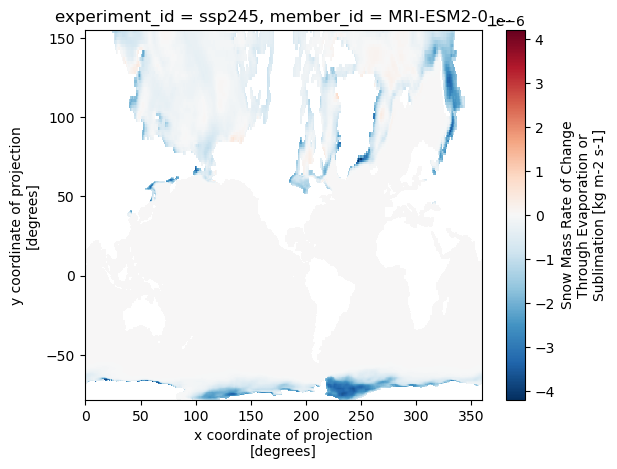

In [7]:
try:
    CMIP6_evap_subl_snow.sndmasssubl.isel(time=0,member_id=0).plot()
except:
    pass

In [8]:
try:
    CMIP6_wind_drift.sndmasswindrif.isel(time=0,member_id=0).plot()
except:
    pass

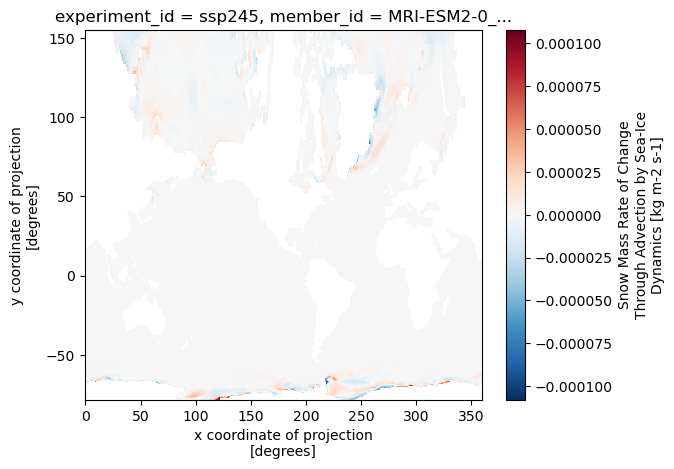

In [9]:
try:
    CMIP6_snow_dynamics.sndmassdyn.isel(time=0,member_id=0).plot()
except:
    pass

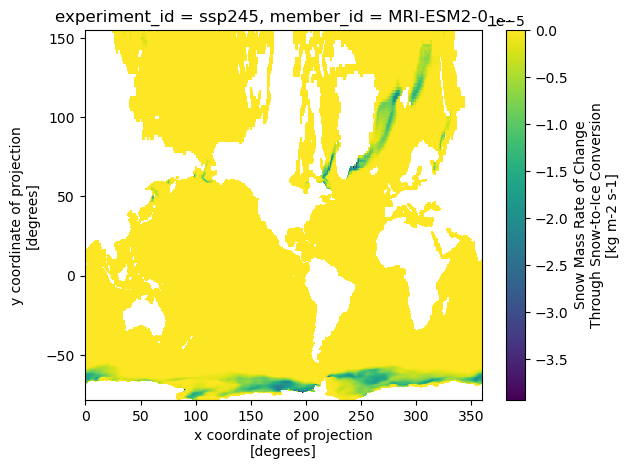

In [10]:
try:
    CMIP6_snow_ice_snow.sndmasssi.isel(time=0,member_id=0).plot()
except:
    pass

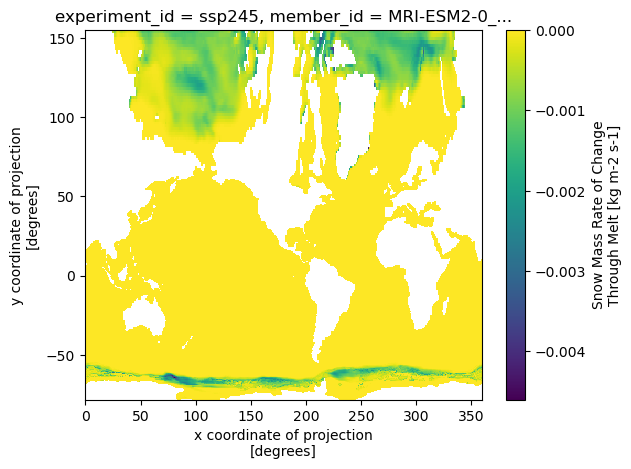

In [11]:
try:
    (CMIP6_snowmelt.sndmassmelt.isel(time=7,member_id=0)*180).plot()
except:
    pass

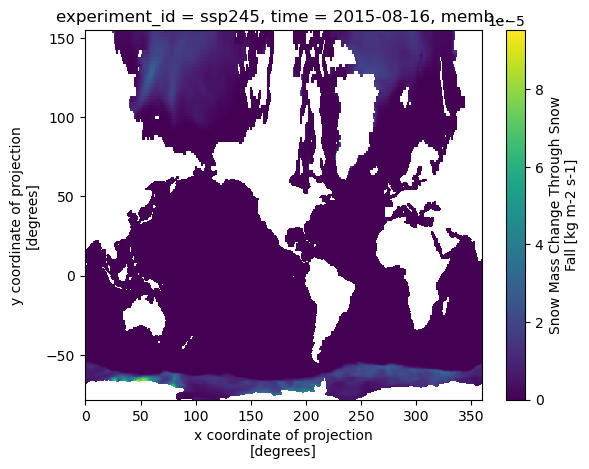

In [12]:
try:
    CMIP6_snowfall.sndmasssnf.isel(time=7,member_id=0).plot()
except:
    pass

In [13]:
####

No documented corrections for 'MRI-ESM2-0' — assuming no siconc scaling, no sign flips, and no magnitude correction. Verify against the raw data before trusting this plot.


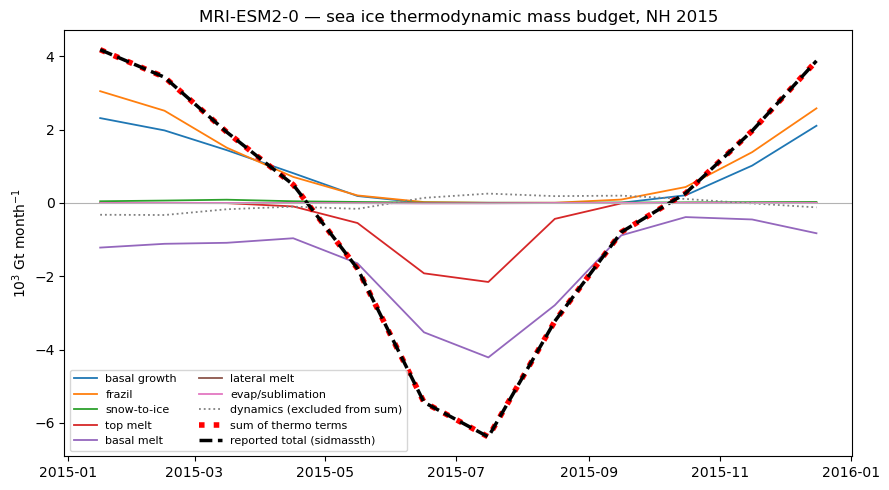

In [88]:
model = models[0]
year = 2015  # change to inspect a different year

# Per-model raw-data corrections, from the "Model notes" markdown cells above (and, for
# CESM-WACCM, from active debugging — unconfirmed, adjust term_scale as you pin it down).
# siconc_scale: growth/melt/evap terms are defined per sea-ice area and need *= siconc/100
#               to become per-grid-cell-area.
# evap_sign:    +1 if sidmassevapsubl is already negative-for-loss in the raw data, -1 if it
#               was published positive and needs flipping.
# melt_sign:    +1 if top/basal/lateral melt are already negative-for-loss, -1 if they were
#               published positive and need flipping.
# scale:        uniform multiplier applied to every raw ice term, on top of term_scale.
# term_scale:   per-term multiplier (keyed by the names used in gt3_NH calls below), for when
#               only some variables need correcting rather than the whole model uniformly.
ICE_CORR = {
    'ACCESS-CM2':      dict(siconc_scale=True,  evap_sign=-1, melt_sign=+1, scale=1, term_scale={}),
    'HadGEM3-GC31-LL': dict(siconc_scale=False, evap_sign=-1, melt_sign=+1, scale=1, term_scale={}),
    'UKESM1-0-LL':     dict(siconc_scale=False, evap_sign=-1, melt_sign=+1, scale=1, term_scale={}),
    'NorESM2-LM':      dict(siconc_scale=False, evap_sign=+1, melt_sign=-1, scale=1, term_scale={}),
    'NorESM2-MM':      dict(siconc_scale=False, evap_sign=+1, melt_sign=-1, scale=1, term_scale={}),
    'CESM2':           dict(siconc_scale=False, evap_sign=+1, melt_sign=-1, scale=1, term_scale={}),
    'CESM2-LE':        dict(siconc_scale=False, evap_sign=+1, melt_sign=-1, scale=1, term_scale={}),
    # UNCONFIRMED: raw growth/melt terms are ~1000-2000x too small relative to sidmassth/
    # sidmassdyn (all declared 'kg m-2 s-1', so it's not a units-label bug — the archived
    # values themselves are off). 1800x was found by tuning against the closure plot below;
    # evap_subl's raw magnitude looked consistent with the others already, so left at 1x.
    # Sign conventions haven't been independently checked.
    'CESM2-WACCM':      dict(siconc_scale=False, evap_sign=+1, melt_sign=-1, scale=1, term_scale={
        'thermo': 1, 'dynamics': 1, 'basal_growth': 1, 'frazil': 1, 'snow_ice': 1,
        'top_melt': 1, 'basal_melt': 1, 'lateral_melt': 1, 'evap_subl': 1/1e6,
    }),
}
corr = ICE_CORR.get(model)
if corr is None:
    print(f"No documented corrections for '{model}' — assuming no siconc scaling, no sign flips, "
          "and no magnitude correction. Verify against the raw data before trusting this plot.")
    corr = dict(siconc_scale=False, evap_sign=+1, melt_sign=+1, scale=1, term_scale={})
elif model == 'CESM2-WACCM':
    print("CESM2-WACCM term_scale values were tuned empirically against this plot, not derived "
          "from documented model corrections — treat this as a debugging aid, not a validated result.")

areacello = CMIP6_thermo.areacello
lat = CMIP6_thermo.lat
siconc_scale_da = (CMIP6_siconc.siconc.isel(member_id=0).sel(time=str(year)) / 100) if corr['siconc_scale'] else 1

def gt3_NH(ds, varname, term, sign=1):
    """Area-integrate a CMIP6 sea-ice mass-flux term over the NH, member 0, in 10^3 Gt/month."""
    extra = corr['term_scale'].get(term, 1)
    da = ds[varname].isel(member_id=0).sel(time=str(year)) * sign * siconc_scale_da * corr['scale'] * extra
    seconds = da.time.dt.days_in_month * 86400
    return (da.squeeze() * areacello).where(lat > 0).sum(['x', 'y']) * seconds / 1e15

thermo_total = gt3_NH(CMIP6_thermo, 'sidmassth', 'thermo')
basal_growth = gt3_NH(CMIP6_basal_growth, 'sidmassgrowthbot', 'basal_growth')
frazil       = gt3_NH(CMIP6_frazil, 'sidmassgrowthwat', 'frazil')
snow_ice     = gt3_NH(CMIP6_snow_ice, 'sidmasssi', 'snow_ice')
top_melt     = gt3_NH(CMIP6_top_melt, 'sidmassmelttop', 'top_melt', sign=corr['melt_sign'])
basal_melt   = gt3_NH(CMIP6_basal_melt, 'sidmassmeltbot', 'basal_melt', sign=corr['melt_sign'])
lateral_melt = gt3_NH(CMIP6_lateral_melt, 'sidmasslat', 'lateral_melt', sign=corr['melt_sign'])
evap_subl    = gt3_NH(CMIP6_evap_subl, 'sidmassevapsubl', 'evap_subl', sign=corr['evap_sign'])
dynamics     = gt3_NH(CMIP6_dynamics, 'sidmassdyn', 'dynamics')  # not thermodynamic — plotted for reference only

thermo_sum = basal_growth + frazil + snow_ice + top_melt + basal_melt + lateral_melt + evap_subl

terms = {
    'basal growth':     (basal_growth, 'tab:blue'),
    'frazil':           (frazil, 'tab:orange'),
    'snow-to-ice':      (snow_ice, 'tab:green'),
    'top melt':         (top_melt, 'tab:red'),
    'basal melt':       (basal_melt, 'tab:purple'),
    'lateral melt':     (lateral_melt, 'tab:brown'),
    'evap/sublimation': (evap_subl, 'tab:pink'),
}

fig, ax = plt.subplots(figsize=(9, 5))
for label, (da, color) in terms.items():
    ax.plot(da.time, da, color=color, lw=1.3, label=label)
ax.plot(dynamics.time, dynamics, color='0.5', lw=1.3, ls=':', label='dynamics (excluded from sum)')
ax.plot(thermo_sum.time, thermo_sum, color='r', lw=4, ls=':', label='sum of thermo terms')
ax.plot(thermo_total.time, thermo_total, color='k',ls='--', lw=2.5, label='reported total (sidmassth)')
ax.axhline(0, color='0.7', lw=0.8)
#ax.set_ylim(-1,1)
ax.set_ylabel(r'$10^3$ Gt month$^{-1}$')
ax.set_title(f'{model} — sea ice thermodynamic mass budget, NH {year}')
ax.legend(ncol=2, fontsize=8, loc='best')
plt.tight_layout()
plt.show()


No documented corrections for 'MRI-ESM2-0' — assuming no siconc scaling, no sign flips, and no magnitude correction. Verify against the raw data before trusting this plot.


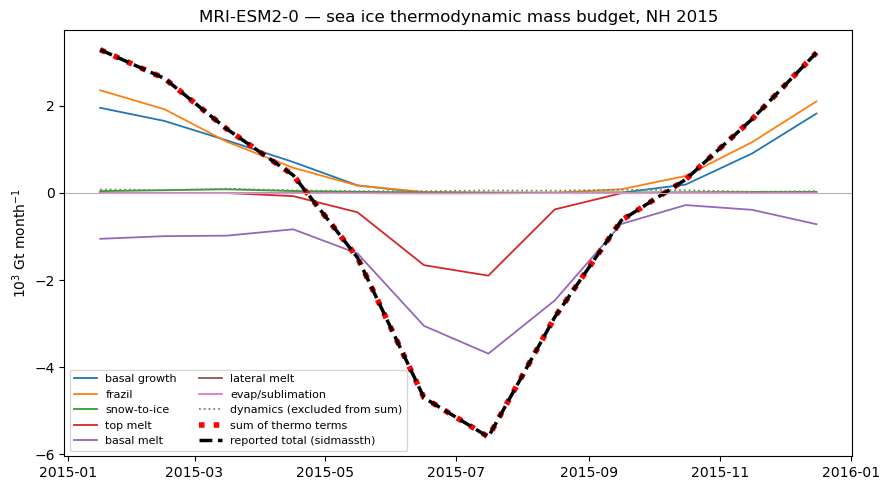

In [112]:
model = models[0]
year = 2015  # change to inspect a different year

# Per-model raw-data corrections, from the "Model notes" markdown cells above (and, for
# CESM-WACCM, from active debugging — unconfirmed, adjust term_scale as you pin it down).
# siconc_scale: growth/melt/evap terms are defined per sea-ice area and need *= siconc/100
#               to become per-grid-cell-area.
# evap_sign:    +1 if sidmassevapsubl is already negative-for-loss in the raw data, -1 if it
#               was published positive and needs flipping.
# melt_sign:    +1 if top/basal/lateral melt are already negative-for-loss, -1 if they were
#               published positive and need flipping.
# scale:        uniform multiplier applied to every raw ice term, on top of term_scale.
# term_scale:   per-term multiplier (keyed by the names used in gt3_NH calls below), for when
#               only some variables need correcting rather than the whole model uniformly.
ICE_CORR = {
    'ACCESS-CM2':      dict(siconc_scale=True,  evap_sign=-1, melt_sign=+1, scale=1, term_scale={}),
    'HadGEM3-GC31-LL': dict(siconc_scale=False, evap_sign=-1, melt_sign=+1, scale=1, term_scale={}),
    'UKESM1-0-LL':     dict(siconc_scale=False, evap_sign=-1, melt_sign=+1, scale=1, term_scale={}),
    'NorESM2-LM':      dict(siconc_scale=False, evap_sign=+1, melt_sign=-1, scale=1, term_scale={}),
    'NorESM2-MM':      dict(siconc_scale=False, evap_sign=+1, melt_sign=-1, scale=1, term_scale={}),
    'CESM2':           dict(siconc_scale=False, evap_sign=+1, melt_sign=-1, scale=1, term_scale={}),
    'CESM2-LE':        dict(siconc_scale=False, evap_sign=+1, melt_sign=-1, scale=1, term_scale={}),
    # UNCONFIRMED: raw growth/melt terms are ~1000-2000x too small relative to sidmassth/
    # sidmassdyn (all declared 'kg m-2 s-1', so it's not a units-label bug — the archived
    # values themselves are off). 1800x was found by tuning against the closure plot below;
    # evap_subl's raw magnitude looked consistent with the others already, so left at 1x.
    # Sign conventions haven't been independently checked.
    'CESM2-WACCM':      dict(siconc_scale=False, evap_sign=+1, melt_sign=-1, scale=1, term_scale={
        'thermo': 1, 'dynamics': 1, 'basal_growth': 1, 'frazil': 1, 'snow_ice': 1,
        'top_melt': 1, 'basal_melt': 1, 'lateral_melt': 1, 'evap_subl': 1/1e6,
    }),
}
corr = ICE_CORR.get(model)
if corr is None:
    print(f"No documented corrections for '{model}' — assuming no siconc scaling, no sign flips, "
          "and no magnitude correction. Verify against the raw data before trusting this plot.")
    corr = dict(siconc_scale=False, evap_sign=+1, melt_sign=+1, scale=1, term_scale={})
elif model == 'CESM2-WACCM':
    print("CESM2-WACCM term_scale values were tuned empirically against this plot, not derived "
          "from documented model corrections — treat this as a debugging aid, not a validated result.")

areacello = CMIP6_thermo.areacello
lat = CMIP6_thermo.lat
siconc_scale_da = (CMIP6_siconc.siconc.isel(member_id=0).sel(time=str(year)) / 100) if corr['siconc_scale'] else 1

def gt3_NH(ds, varname, term, sign=1):
    """Area-integrate a CMIP6 sea-ice mass-flux term over the NH, member 0, in 10^3 Gt/month."""
    extra = corr['term_scale'].get(term, 1)
    da = ds[varname].isel(member_id=0).sel(time=str(year)) * sign * siconc_scale_da * corr['scale'] * extra
    seconds = da.time.dt.days_in_month * 86400
    return (da.squeeze() * areacello).where(lat > 0).sum(['x', 'y']) * seconds / 1e15

thermo_total = gt3_NH(CMIP6_thermo, 'sidmassth', 'thermo')
basal_growth = gt3_NH(CMIP6_basal_growth, 'sidmassgrowthbot', 'basal_growth')
frazil       = gt3_NH(CMIP6_frazil, 'sidmassgrowthwat', 'frazil')
snow_ice     = gt3_NH(CMIP6_snow_ice, 'sidmasssi', 'snow_ice')
top_melt     = gt3_NH(CMIP6_top_melt, 'sidmassmelttop', 'top_melt', sign=corr['melt_sign'])
basal_melt   = gt3_NH(CMIP6_basal_melt, 'sidmassmeltbot', 'basal_melt', sign=corr['melt_sign'])
lateral_melt = gt3_NH(CMIP6_lateral_melt, 'sidmasslat', 'lateral_melt', sign=corr['melt_sign'])
evap_subl    = gt3_NH(CMIP6_evap_subl, 'sidmassevapsubl', 'evap_subl', sign=corr['evap_sign'])
dynamics     = gt3_NH(CMIP6_dynamics, 'sidmassdyn', 'dynamics')  # not thermodynamic — plotted for reference only

thermo_sum = basal_growth + frazil + snow_ice + top_melt + basal_melt + lateral_melt + evap_subl

terms = {
    'basal growth':     (basal_growth, 'tab:blue'),
    'frazil':           (frazil, 'tab:orange'),
    'snow-to-ice':      (snow_ice, 'tab:green'),
    'top melt':         (top_melt, 'tab:red'),
    'basal melt':       (basal_melt, 'tab:purple'),
    'lateral melt':     (lateral_melt, 'tab:brown'),
    'evap/sublimation': (evap_subl, 'tab:pink'),
}

fig, ax = plt.subplots(figsize=(9, 5))
for label, (da, color) in terms.items():
    ax.plot(da.time, da, color=color, lw=1.3, label=label)
ax.plot(dynamics.time, dynamics, color='0.5', lw=1.3, ls=':', label='dynamics (excluded from sum)')
ax.plot(thermo_sum.time, thermo_sum, color='r', lw=4, ls=':', label='sum of thermo terms')
ax.plot(thermo_total.time, thermo_total, color='k',ls='--', lw=2.5, label='reported total (sidmassth)')
ax.axhline(0, color='0.7', lw=0.8)
#ax.set_ylim(-1,1)
ax.set_ylabel(r'$10^3$ Gt month$^{-1}$')
ax.set_title(f'{model} — sea ice thermodynamic mass budget, NH {year}')
ax.legend(ncol=2, fontsize=8, loc='best')
plt.tight_layout()
plt.show()

No documented corrections for 'MRI-ESM2-0' — assuming no siconc scaling, no sign flip, and no magnitude correction. Verify against the raw data before trusting this plot.
Skipping 'wind drift' for MRI-ESM2-0: TypeError ('NoneType' object is not subscriptable)


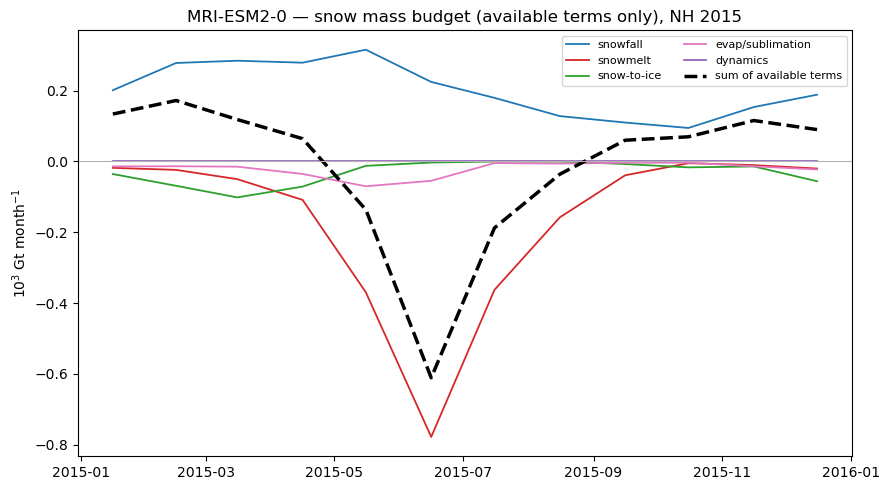

In [15]:
model = models[0]
year = 2015  # keep in sync with the ice-budget cell above

# Sign/scale convention per model, from the "Model notes" markdown cell above (and, for
# CESM-WACCM, from active debugging — unconfirmed, adjust `scale` as you pin it down).
# term_scale applies an additional per-term fudge factor documented in that same cell
# (ACCESS-CM2 snowmelt/3.3 ~ snow density/100; NorESM2 snowfall/330 ~ snow density).
SNOW_CORR = {
    'ACCESS-CM2':      dict(siconc_scale=True,  melt_sign=+1, scale=1, term_scale={'snowmelt': 1/3.3}),
    'HadGEM3-GC31-LL': dict(siconc_scale=False, melt_sign=+1, scale=1, term_scale={}),
    'UKESM1-0-LL':     dict(siconc_scale=False, melt_sign=+1, scale=1, term_scale={}),
    'NorESM2-LM':      dict(siconc_scale=False, melt_sign=-1, scale=1, term_scale={'snowfall': 1/330}),
    'NorESM2-MM':      dict(siconc_scale=False, melt_sign=-1, scale=1, term_scale={'snowfall': 1/330}),
    'CESM2':           dict(siconc_scale=False, melt_sign=-1, scale=1, term_scale={}),
    'CESM2-LE':        dict(siconc_scale=False, melt_sign=-1, scale=1, term_scale={}),
    # UNCONFIRMED: raw terms look ~10^3 too small — guessing a unit mismatch. Sign conventions
    # and per-term fudge factors haven't been checked yet; verify against the raw files.
    'CESM2-WACCM':      dict(siconc_scale=False, melt_sign=-1, scale=1, term_scale={'snowmelt': 1,'snowfall': 1/330}),
}
scorr = SNOW_CORR.get(model)
if scorr is None:
    print(f"No documented corrections for '{model}' — assuming no siconc scaling, no sign flip, "
          "and no magnitude correction. Verify against the raw data before trusting this plot.")
    scorr = dict(siconc_scale=False, melt_sign=+1, scale=1, term_scale={})
elif model == 'CESM2-WACCM':
    print("CESM2-WACCM corrections are still being worked out (scale=1000 is a guess) — "
          "treat this plot as a debugging aid, not a validated result.")

areacello = CMIP6_thermo.areacello
lat = CMIP6_thermo.lat
siconc_scale_da = (CMIP6_siconc.siconc.isel(member_id=1).sel(time=str(year)) / 100) if scorr['siconc_scale'] else 1

def gt3_NH_snow(ds, varname, sign=1, term=None):
    """Area-integrate a CMIP6 snow mass-flux term over the NH, member 0, in 10^3 Gt/month."""
    extra = scorr['term_scale'].get(term, 1) if term else 1
    da = ds[varname].isel(member_id=1).sel(time=str(year)) * sign * siconc_scale_da * scorr['scale'] * extra
    seconds = da.time.dt.days_in_month * 86400
    return (da.squeeze() * areacello).where(lat > 0).sum(['x', 'y']) * seconds / 1e15

# (dataset, variable, sign, color) — not every model publishes every one of these
snow_candidates = {
    'snowfall':         (CMIP6_snowfall,       'sndmasssnf',     1,                  'tab:blue'),
    'snowmelt':         (CMIP6_snowmelt,       'sndmassmelt',    scorr['melt_sign'], 'tab:red'),
    'snow-to-ice':      (CMIP6_snow_ice_snow,  'sndmasssi',      1,                  'tab:green'),
    'wind drift':       (CMIP6_wind_drift,     'sndmasswindrif', 1,                  'tab:orange'),
    'evap/sublimation': (CMIP6_evap_subl_snow, 'sndmasssubl',    1,                  'tab:pink'),
    'dynamics':         (CMIP6_snow_dynamics,  'sndmassdyn',     1,                  'tab:purple'),
}

snow_terms = {}
for label, (ds, varname, sign, color) in snow_candidates.items():
    try:
        snow_terms[label] = (gt3_NH_snow(ds, varname, sign=sign, term=label), color)
    except Exception as e:
        print(f"Skipping '{label}' for {model}: {type(e).__name__} ({e})")

fig, ax = plt.subplots(figsize=(9, 5))
for label, (da, color) in snow_terms.items():
    ax.plot(da.time, da, color=color, lw=1.3, label=label)
if snow_terms:
    snow_sum = sum(da for da, _ in snow_terms.values())
    ax.plot(snow_sum.time, snow_sum, color='k', lw=2.5, ls='--', label='sum of available terms')
ax.axhline(0, color='0.7', lw=0.8)
ax.set_ylabel(r'$10^3$ Gt month$^{-1}$')
ax.set_title(f'{model} — snow mass budget (available terms only), NH {year}')
ax.legend(ncol=2, fontsize=8, loc='best')
plt.tight_layout()
plt.show()


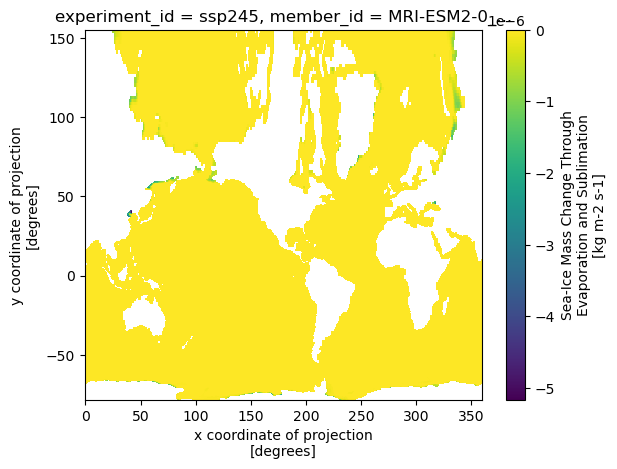

In [17]:
try:
    CMIP6_evap_subl.sidmassevapsubl.isel(time=0,member_id=0).plot()
except:
    pass

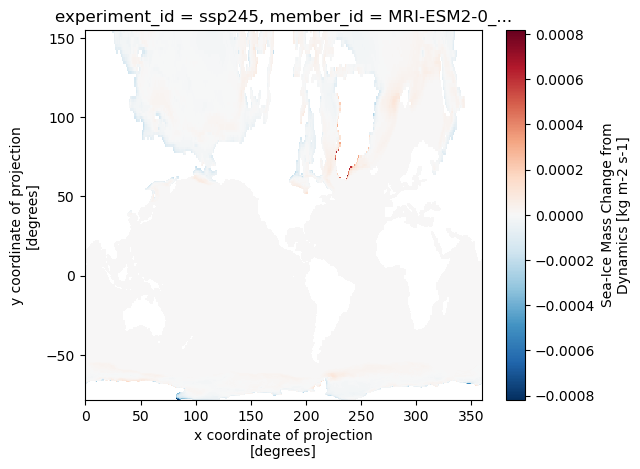

In [97]:
CMIP6_dynamics.sidmassdyn.isel(member_id=0).sel(time='2015').mean('time').plot()

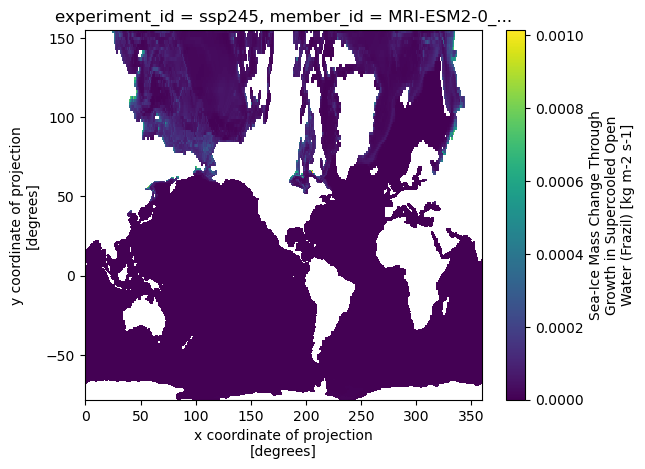

In [19]:
CMIP6_frazil.sidmassgrowthwat.isel(time=0,member_id=0).plot()

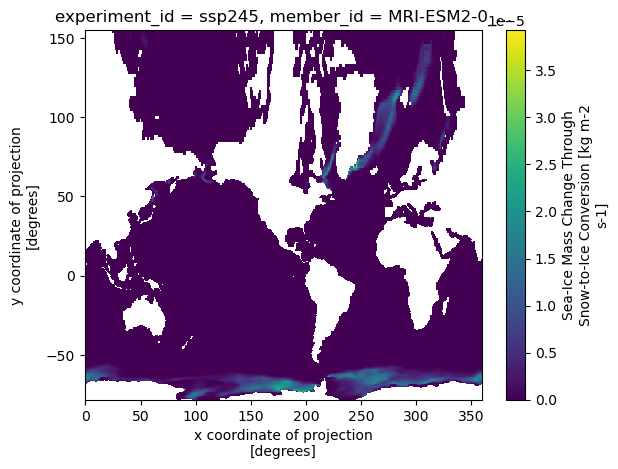

In [20]:
CMIP6_snow_ice.sidmasssi.isel(time=0,member_id=0).plot()

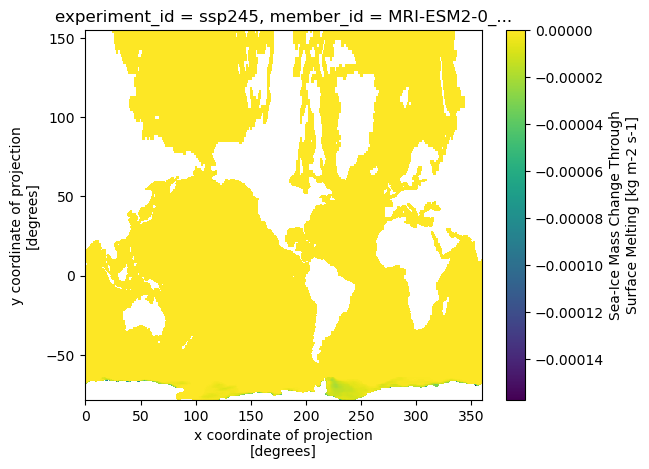

In [21]:
CMIP6_top_melt.sidmassmelttop.isel(time=0,member_id=0).plot()

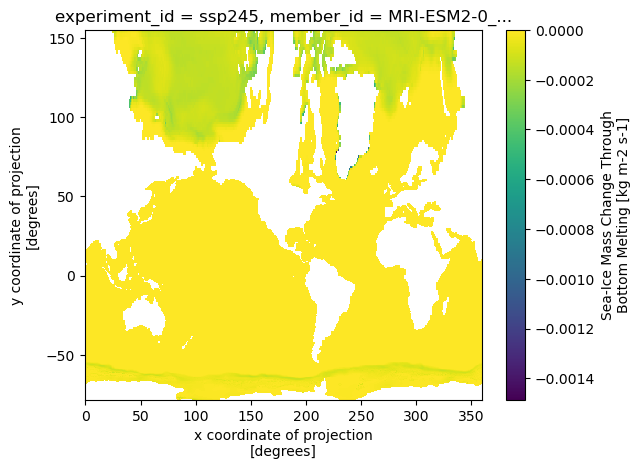

In [22]:
CMIP6_basal_melt.sidmassmeltbot.isel(time=7,member_id=0).plot()

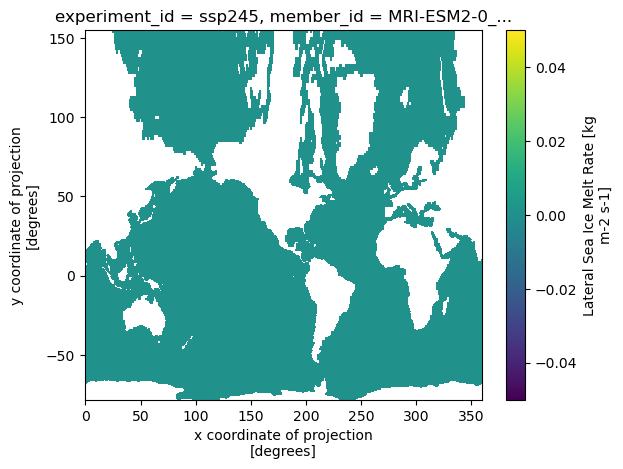

In [23]:
CMIP6_lateral_melt.sidmasslat.isel(time=0,member_id=0).plot()

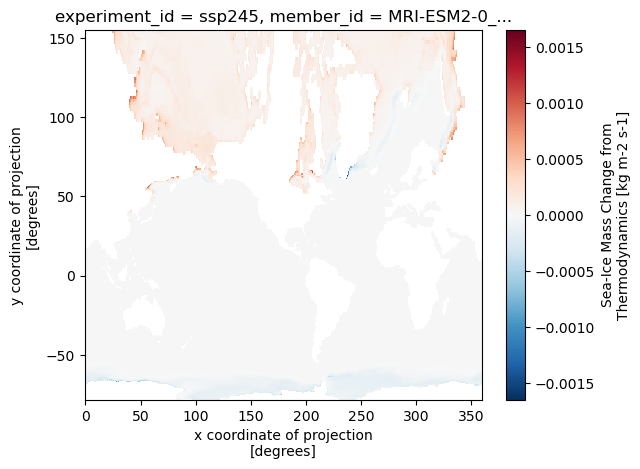

In [61]:
CMIP6_thermo.sidmassth.isel(time=0,member_id=0).plot()

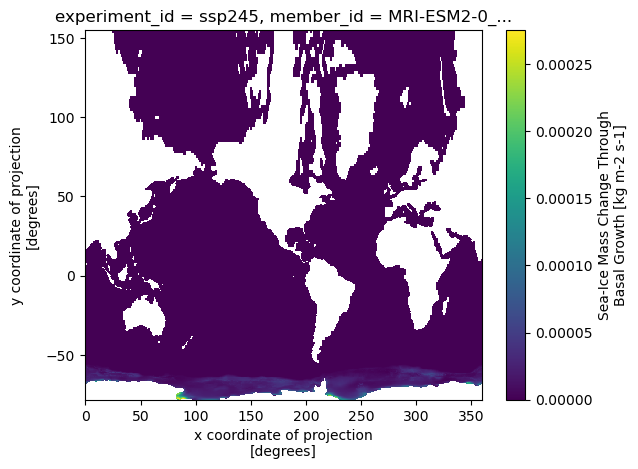

In [25]:
CMIP6_basal_growth.sidmassgrowthbot.isel(time=7,member_id=0).plot()

### Area-integrate snow fluxes (10³ Gt month⁻¹)

 For the inner Arctic Ocean domain, we use Arctic Ocean basin (central Arctic plus the Beaufort, Chukchi, East Siberian, Laptev and Kara seas) and the Barents Sea.
 This is [0,1,2,3,4,5,6,7] in `NH_seaice_regions` from the NSIDC

In [29]:
NH_seaice_regions

,Region,Sea_ID,geometry
0,Central_Arctic,1.0,"POLYGON ((-180 76.0917, -180 90, 180 90, 180 7..."
1,Beaufort,2.0,"POLYGON ((-123.0167 76.0917, -124.7667 74.3417..."
2,Chukchi-NA,3.0,"POLYGON ((-156.4667 76.0917, -156.4667 71.384,..."
3,Chukchi-Asia,3.0,"POLYGON ((180 76.0917, 180 66.5635, 178.75 66...."
4,E_Siberian,4.0,"POLYGON ((178.75 76.0917, 178.75 70.78, 178.75..."
5,Laptev,5.0,"POLYGON ((138.8333 76.0917, 140.5833 74.0083, ..."
6,Kara,6.0,"POLYGON ((95.25 81.2167, 100.3561 79.6603, 102..."
7,Barents,7.0,"POLYGON ((65 81, 68.6 76.8, 62.3 75.8, 58.5 75..."
8,E_Greenland,8.0,"POLYGON ((18 78.75, 17.15 77.75, 17 77, 16.7 7..."
9,Baffin,9.0,"POLYGON ((-45 80, -45 57, -45 44, -53.1 44, -5..."


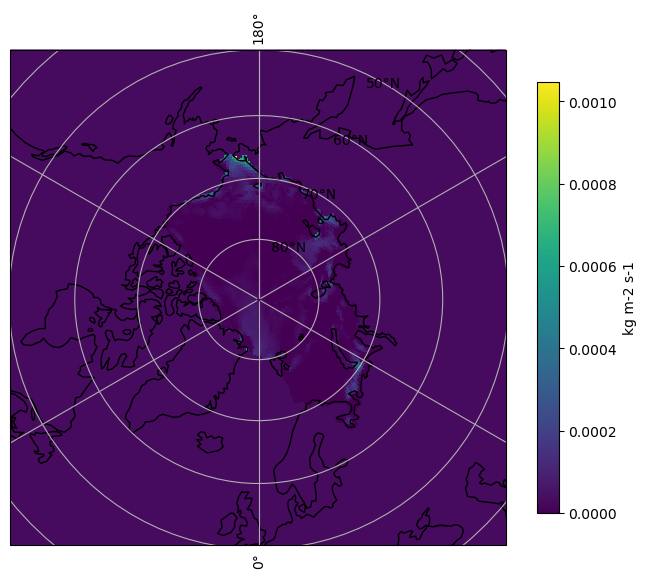

In [95]:
da = region_mask(
    CMIP6_dynamics.sidmassdyn.isel(time=0, member_id=0),
    {'Arctic': [0,1,2,3,4,5,6,7]}
).squeeze()

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())

p = ax.pcolormesh(
    da.lon, da.lat, da,
    transform=ccrs.PlateCarree(),   # tells cartopy the data coords are plain lat/lon
    cmap='viridis',
    shading='auto',vmin=0
)

#ax.add_feature(cfeature.LAND, zorder=100, facecolor='lightgray')
ax.coastlines()
ax.gridlines(draw_labels=True)
plt.colorbar(p, ax=ax, orientation='vertical', shrink=0.7, label=da.attrs.get('units',''))
plt.show()

Model notes:

- ACCESS-CM2:
    - All variables are defined per sea ice area and were converted to grid cell area
    - It is not a documented error, but the snowmelt appears much larger than physically possible. In an attempt to fix, snowmelt terms were divided by 3.3 (snow density/100).
    - sndmasswindrif and sndmasssubl are unavailable
- HadGEM3-GC31-LL and UKESM1-0-LL
    - sndmasswindrif and sndmasssubl are unavailable
- NorESM-LM and MM
    - Snowmelt was defined positive and switched to a negative flux.
    - Snowfall also need to be divided by snow density (330).
    - sndmasssubl and sndmassdyn are unavailable
- CESM2
    - Snowmelt was defined positive and switched to a negative flux.
- CESM2-WACCM
    - Snowmelt was defined positive and switched to a negative flux.
    - Correction is per-member, not model-wide: only the first member (r1i1p1f1) has archived snowmelt that is 1800x too small (same 30-minute/1800s coupling-interval issue as the ice-budget terms below); other members are archived correctly and are left unscaled.
    - Only the third member (r3i1p1f1) has archived snowfall that is ~330x too large (same snow-density-unit issue as NorESM2's fix); other members' snowfall is archived correctly.
    - sndmasssubl (unlike other models) is available for CESM2-WACCM, but is left unscaled since its magnitude hasn't been checked. Snow-to-ice and wind drift also not yet checked.
- MRI-ESM2-0
    - No corrections needed.
    - sndmasswindrif is unavailable

In [64]:
seconds = CMIP6_siconc.time.dt.days_in_month * 86400

if models[0] == 'ACCESS-CM2':
    CMIP6_snowmelt_SH      = (((CMIP6_snowmelt*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt/3.3
    CMIP6_snowmelt_Weddell = ((region_mask(CMIP6_snowmelt*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt/3.3
    CMIP6_snowmelt_NH      = (((CMIP6_snowmelt*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt/3.3
    CMIP6_snowmelt_IA      = ((region_mask(CMIP6_snowmelt*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt/3.3
    
    CMIP6_snowfall_SH      = (((CMIP6_snowfall*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_Weddell = ((region_mask(CMIP6_snowfall*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_NH      = (((CMIP6_snowfall*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_IA      = ((region_mask(CMIP6_snowfall*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    
    CMIP6_snow_ice_snow_SH      = (((CMIP6_snow_ice_snow*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_Weddell = ((region_mask(CMIP6_snow_ice_snow*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_NH      = (((CMIP6_snow_ice_snow*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_IA      = ((region_mask(CMIP6_snow_ice_snow*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    
    CMIP6_snow_dynamics_SH      = (((CMIP6_snow_dynamics*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn
    CMIP6_snow_dynamics_Weddell = ((region_mask(CMIP6_snow_dynamics*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn
    CMIP6_snow_dynamics_NH      = (((CMIP6_snow_dynamics*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn
    CMIP6_snow_dynamics_IA      = ((region_mask(CMIP6_snow_dynamics*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn

if models[0] in ['HadGEM3-GC31-LL','UKESM1-0-LL']:
    CMIP6_snowmelt_SH      = (((CMIP6_snowmelt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_Weddell = ((region_mask(CMIP6_snowmelt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_NH      = (((CMIP6_snowmelt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_IA      = ((region_mask(CMIP6_snowmelt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    
    CMIP6_snowfall_SH      = (((CMIP6_snowfall).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_Weddell = ((region_mask(CMIP6_snowfall,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_NH      = (((CMIP6_snowfall).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_IA      = ((region_mask(CMIP6_snowfall,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    
    CMIP6_snow_ice_snow_SH      = (((CMIP6_snow_ice_snow).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_Weddell = ((region_mask(CMIP6_snow_ice_snow,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_NH      = (((CMIP6_snow_ice_snow).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_IA      = ((region_mask(CMIP6_snow_ice_snow,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    
    CMIP6_snow_dynamics_SH      = (((CMIP6_snow_dynamics).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn
    CMIP6_snow_dynamics_Weddell = ((region_mask(CMIP6_snow_dynamics,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn
    CMIP6_snow_dynamics_NH      = (((CMIP6_snow_dynamics).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn
    CMIP6_snow_dynamics_IA      = ((region_mask(CMIP6_snow_dynamics,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn

if models[0] in ['NorESM2-LM','NorESM2-MM']:

    CMIP6_snowmelt_SH      = -(((CMIP6_snowmelt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_Weddell = -((region_mask(CMIP6_snowmelt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_NH      = -(((CMIP6_snowmelt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_IA      = -((region_mask(CMIP6_snowmelt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    
    CMIP6_snowfall_SH      = (((CMIP6_snowfall).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf/330
    CMIP6_snowfall_Weddell = ((region_mask(CMIP6_snowfall,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf/330
    CMIP6_snowfall_NH      = (((CMIP6_snowfall).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf/330
    CMIP6_snowfall_IA      = ((region_mask(CMIP6_snowfall,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf/330

    CMIP6_snow_ice_snow_SH      = (((CMIP6_snow_ice_snow).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_Weddell = ((region_mask(CMIP6_snow_ice_snow,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_NH      = (((CMIP6_snow_ice_snow).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_IA      = ((region_mask(CMIP6_snow_ice_snow,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    
    CMIP6_wind_drift_SH      = (((CMIP6_wind_drift).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasswindrif
    CMIP6_wind_drift_Weddell = ((region_mask(CMIP6_wind_drift,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasswindrif
    CMIP6_wind_drift_NH      = (((CMIP6_wind_drift).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasswindrif
    CMIP6_wind_drift_IA      = ((region_mask(CMIP6_wind_drift,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasswindrif

if models[0] in ['CESM2']:
    CMIP6_snowmelt_SH      = -(((CMIP6_snowmelt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_Weddell = -((region_mask(CMIP6_snowmelt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_NH      = -(((CMIP6_snowmelt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_IA      = -((region_mask(CMIP6_snowmelt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    
    CMIP6_snowfall_SH      = (((CMIP6_snowfall).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_Weddell = ((region_mask(CMIP6_snowfall,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_NH      = (((CMIP6_snowfall).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_IA      = ((region_mask(CMIP6_snowfall,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf

if models[0] == 'CESM2-WACCM':
    # Only the first ensemble member (r1i1p1f1) has archived snowmelt that is 1800x too
    # small (matches the ice budget's 30-minute/1800s coupling-interval bug below); the
    # other members are archived correctly and must not be rescaled. Separately, only the
    # third member (r3i1p1f1) has archived snowfall that is ~330x too large (same snow-
    # density-unit issue as NorESM2's snowfall/330 fix); the other members' snowfall is
    # archived correctly. sndmasssubl (unlike other models) is available for CESM2-WACCM;
    # unscaled since its magnitude hasn't been checked. snow-to-ice and wind drift not yet
    # checked.
    waccm_member0 = CMIP6_snowmelt.member_id == 'CESM2-WACCM_r1i1p1f1'
    waccm_member2 = CMIP6_snowfall.member_id == 'CESM2-WACCM_r2i1p1f1'
    snowmelt_scale = xr.where(waccm_member0, 1800, 1)
    snowfall_scale = xr.where(waccm_member2, 1/330, 1)

    CMIP6_snowmelt_SH      = -(((CMIP6_snowmelt*snowmelt_scale).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_Weddell = -((region_mask(CMIP6_snowmelt*snowmelt_scale,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_NH      = -(((CMIP6_snowmelt*snowmelt_scale).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_IA      = -((region_mask(CMIP6_snowmelt*snowmelt_scale,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    
    CMIP6_snowfall_SH      = (((CMIP6_snowfall*snowfall_scale).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_Weddell = ((region_mask(CMIP6_snowfall*snowfall_scale,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_NH      = (((CMIP6_snowfall*snowfall_scale).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_IA      = ((region_mask(CMIP6_snowfall*snowfall_scale,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    
    CMIP6_evap_subl_snow_SH      = (((CMIP6_evap_subl_snow).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssubl
    CMIP6_evap_subl_snow_Weddell = ((region_mask(CMIP6_evap_subl_snow,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssubl
    CMIP6_evap_subl_snow_NH      = (((CMIP6_evap_subl_snow).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssubl
    CMIP6_evap_subl_snow_IA      = ((region_mask(CMIP6_evap_subl_snow,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssubl

if models[0] == 'MRI-ESM2-0':
    # No corrections needed: archived terms already follow the CF sign convention
    # (negative-for-loss) with no unit/magnitude issues. sndmasswindrif is unavailable.
    CMIP6_snowmelt_SH      = (((CMIP6_snowmelt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_Weddell = ((region_mask(CMIP6_snowmelt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_NH      = (((CMIP6_snowmelt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    CMIP6_snowmelt_IA      = ((region_mask(CMIP6_snowmelt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassmelt
    
    CMIP6_snowfall_SH      = (((CMIP6_snowfall).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_Weddell = ((region_mask(CMIP6_snowfall,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_NH      = (((CMIP6_snowfall).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    CMIP6_snowfall_IA      = ((region_mask(CMIP6_snowfall,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssnf
    
    CMIP6_snow_ice_snow_SH      = (((CMIP6_snow_ice_snow).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_Weddell = ((region_mask(CMIP6_snow_ice_snow,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_NH      = (((CMIP6_snow_ice_snow).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    CMIP6_snow_ice_snow_IA      = ((region_mask(CMIP6_snow_ice_snow,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssi
    
    CMIP6_snow_dynamics_SH      = (((CMIP6_snow_dynamics).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn
    CMIP6_snow_dynamics_Weddell = ((region_mask(CMIP6_snow_dynamics,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn
    CMIP6_snow_dynamics_NH      = (((CMIP6_snow_dynamics).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn
    CMIP6_snow_dynamics_IA      = ((region_mask(CMIP6_snow_dynamics,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmassdyn
    
    CMIP6_evap_subl_snow_SH      = (((CMIP6_evap_subl_snow).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssubl
    CMIP6_evap_subl_snow_Weddell = ((region_mask(CMIP6_evap_subl_snow,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssubl
    CMIP6_evap_subl_snow_NH      = (((CMIP6_evap_subl_snow).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssubl
    CMIP6_evap_subl_snow_IA      = ((region_mask(CMIP6_evap_subl_snow,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sndmasssubl


### Area-integrate ice fluxes (10³ Gt month⁻¹)

- ACCESS-CM2:
    - Thermodynamics and dynamics are defined relative to grid cell area
    - All other variables are incorrectly defined relative to sea ice area and need to be scaled by `siconc/100` before computing the spatial sum.
    - sidmassevapsubl (evaporation and sublimation) was defined positive in the model output and has been changed to negative
- HadGEM3-GC31-LL and UKESM1-0-LL
    - sidmassevapsubl (evaporation and sublimation) was defined positive in the model output and has been changed to negative
- NorESM-LM, MM, and CESM2
    - Melt terms (top melt: sidmassmelttop, basal melt: sidmassmeltbot, and lateral melt: sidmasslat) were defined positive in the model output and have been changed to negative
- CESM2-WACCM
    - Correction is per-member, not model-wide. Only the first member (r1i1p1f1) has basal_growth, frazil, snow_ice, top_melt, basal_melt, and lateral_melt archived 1800x too small (matches CESM2's 30-minute/1800s ice-ocean coupling interval, though the root cause in the diagnostic pipeline hasn't been confirmed); other members are archived correctly.
    - Conversely, evap_subl is 1e6x too large in every member except the first, which is already correct as archived.
    - thermo and dynamics did not need correction in any member.
- MRI-ESM2-0
    - No corrections needed.

In [65]:
if models[0] == 'ACCESS-CM2':

    CMIP6_thermo_SH = (((CMIP6_thermo).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_NH = (((CMIP6_thermo).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_Weddell = ((region_mask(CMIP6_thermo,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_IA = ((region_mask(CMIP6_thermo,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    
    CMIP6_basal_growth_SH = (((CMIP6_basal_growth*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_NH = (((CMIP6_basal_growth*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_Weddell = ((region_mask(CMIP6_basal_growth*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_IA = ((region_mask(CMIP6_basal_growth*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    
    CMIP6_frazil_SH = (((CMIP6_frazil*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_NH = (((CMIP6_frazil*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_Weddell = ((region_mask(CMIP6_frazil*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_IA = ((region_mask(CMIP6_frazil*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    
    CMIP6_snow_ice_SH = (((CMIP6_snow_ice*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_NH = (((CMIP6_snow_ice*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_Weddell = ((region_mask(CMIP6_snow_ice*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_IA = ((region_mask(CMIP6_snow_ice*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    
    CMIP6_top_melt_SH = (((CMIP6_top_melt*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_NH = (((CMIP6_top_melt*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_Weddell = ((region_mask(CMIP6_top_melt*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_IA = ((region_mask(CMIP6_top_melt*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    
    CMIP6_basal_melt_SH = (((CMIP6_basal_melt*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_NH = (((CMIP6_basal_melt*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_Weddell = ((region_mask(CMIP6_basal_melt*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_IA = ((region_mask(CMIP6_basal_melt*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    
    CMIP6_lateral_melt_SH = (((CMIP6_lateral_melt*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_NH = (((CMIP6_lateral_melt*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_Weddell = ((region_mask(CMIP6_lateral_melt*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_IA = ((region_mask(CMIP6_lateral_melt*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    
    CMIP6_evap_subl_SH = -(((CMIP6_evap_subl*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_NH = -(((CMIP6_evap_subl*(CMIP6_siconc.siconc/100)).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_Weddell = -((region_mask(CMIP6_evap_subl*(CMIP6_siconc.siconc/100),{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_IA = -((region_mask(CMIP6_evap_subl*(CMIP6_siconc.siconc/100),{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    
    CMIP6_dynamics_SH = (((CMIP6_dynamics).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_NH = (((CMIP6_dynamics).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_Weddell = ((region_mask(CMIP6_dynamics,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_IA = ((region_mask(CMIP6_dynamics,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    
if models[0] in ['HadGEM3-GC31-LL','UKESM1-0-LL']:

    CMIP6_thermo_SH = (((CMIP6_thermo).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_NH = (((CMIP6_thermo).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_Weddell = ((region_mask(CMIP6_thermo,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_IA = ((region_mask(CMIP6_thermo,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    
    CMIP6_basal_growth_SH = (((CMIP6_basal_growth).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_NH = (((CMIP6_basal_growth).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_Weddell = ((region_mask(CMIP6_basal_growth,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_IA = ((region_mask(CMIP6_basal_growth,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    
    CMIP6_frazil_SH = (((CMIP6_frazil).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_NH = (((CMIP6_frazil).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_Weddell = ((region_mask(CMIP6_frazil,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_IA = ((region_mask(CMIP6_frazil,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    
    CMIP6_snow_ice_SH = (((CMIP6_snow_ice).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_NH = (((CMIP6_snow_ice).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_Weddell = ((region_mask(CMIP6_snow_ice,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_IA = ((region_mask(CMIP6_snow_ice,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    
    CMIP6_top_melt_SH = (((CMIP6_top_melt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_NH = (((CMIP6_top_melt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_Weddell = ((region_mask(CMIP6_top_melt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_IA = ((region_mask(CMIP6_top_melt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    
    CMIP6_basal_melt_SH = (((CMIP6_basal_melt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_NH = (((CMIP6_basal_melt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_Weddell = ((region_mask(CMIP6_basal_melt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_IA = ((region_mask(CMIP6_basal_melt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    
    CMIP6_lateral_melt_SH = (((CMIP6_lateral_melt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_NH = (((CMIP6_lateral_melt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_Weddell = ((region_mask(CMIP6_lateral_melt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_IA = ((region_mask(CMIP6_lateral_melt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    
    CMIP6_evap_subl_SH = -(((CMIP6_evap_subl).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_NH = -(((CMIP6_evap_subl).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_Weddell = -((region_mask(CMIP6_evap_subl,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_IA = -((region_mask(CMIP6_evap_subl,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    
    CMIP6_dynamics_SH = (((CMIP6_dynamics).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_NH = (((CMIP6_dynamics).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_Weddell = ((region_mask(CMIP6_dynamics,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_IA = ((region_mask(CMIP6_dynamics,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    
if models[0] in ['NorESM2-LM','NorESM2-MM','CESM2']:

    CMIP6_thermo_SH = (((CMIP6_thermo).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_NH = (((CMIP6_thermo).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_Weddell = ((region_mask(CMIP6_thermo,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_IA = ((region_mask(CMIP6_thermo,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    
    CMIP6_basal_growth_SH = (((CMIP6_basal_growth).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_NH = (((CMIP6_basal_growth).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_Weddell = ((region_mask(CMIP6_basal_growth,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_IA = ((region_mask(CMIP6_basal_growth,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    
    CMIP6_frazil_SH = (((CMIP6_frazil).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_NH = (((CMIP6_frazil).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_Weddell = ((region_mask(CMIP6_frazil,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_IA = ((region_mask(CMIP6_frazil,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    
    CMIP6_snow_ice_SH = (((CMIP6_snow_ice).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_NH = (((CMIP6_snow_ice).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_Weddell = ((region_mask(CMIP6_snow_ice,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_IA = ((region_mask(CMIP6_snow_ice,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    
    CMIP6_top_melt_SH = -(((CMIP6_top_melt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_NH = -(((CMIP6_top_melt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_Weddell = -((region_mask(CMIP6_top_melt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_IA = -((region_mask(CMIP6_top_melt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    
    CMIP6_basal_melt_SH = -(((CMIP6_basal_melt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_NH = -(((CMIP6_basal_melt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_Weddell = -((region_mask(CMIP6_basal_melt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_IA = -((region_mask(CMIP6_basal_melt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    
    CMIP6_lateral_melt_SH = -(((CMIP6_lateral_melt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_NH = -(((CMIP6_lateral_melt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_Weddell = -((region_mask(CMIP6_lateral_melt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_IA = -((region_mask(CMIP6_lateral_melt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    
    CMIP6_evap_subl_SH = (((CMIP6_evap_subl).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_NH = (((CMIP6_evap_subl).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_Weddell = ((region_mask(CMIP6_evap_subl,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_IA = ((region_mask(CMIP6_evap_subl,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    
    CMIP6_dynamics_SH = (((CMIP6_dynamics).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_NH = (((CMIP6_dynamics).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_Weddell = ((region_mask(CMIP6_dynamics,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_IA = ((region_mask(CMIP6_dynamics,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    
if models[0] == 'CESM2-WACCM':
    # Only the first ensemble member (r1i1p1f1) has archived basal_growth/frazil/snow_ice/
    # top_melt/basal_melt/lateral_melt terms that are 1800x too small (matches CESM2's
    # 30-minute/1800s ice-ocean coupling interval, though the root cause in the diagnostic
    # pipeline hasn't been confirmed); the other members are archived correctly. Conversely,
    # evap_subl is 1e6x too large in every member except the first, which is already correct
    # as archived. thermo and dynamics did not need correction in any member.
    waccm_member0 = CMIP6_thermo.member_id == 'CESM2-WACCM_r1i1p1f1'
    growth_melt_scale = xr.where(waccm_member0, 1800, 1)
    evap_subl_scale = xr.where(waccm_member0, 1, 1/1e6)

    CMIP6_thermo_SH = (((CMIP6_thermo).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_NH = (((CMIP6_thermo).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_Weddell = ((region_mask(CMIP6_thermo,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_IA = ((region_mask(CMIP6_thermo,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    
    CMIP6_basal_growth_SH = (((CMIP6_basal_growth*growth_melt_scale).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_NH = (((CMIP6_basal_growth*growth_melt_scale).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_Weddell = ((region_mask(CMIP6_basal_growth*growth_melt_scale,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_IA = ((region_mask(CMIP6_basal_growth*growth_melt_scale,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    
    CMIP6_frazil_SH = (((CMIP6_frazil*growth_melt_scale).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_NH = (((CMIP6_frazil*growth_melt_scale).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_Weddell = ((region_mask(CMIP6_frazil*growth_melt_scale,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_IA = ((region_mask(CMIP6_frazil*growth_melt_scale,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    
    CMIP6_snow_ice_SH = (((CMIP6_snow_ice*growth_melt_scale).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_NH = (((CMIP6_snow_ice*growth_melt_scale).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_Weddell = ((region_mask(CMIP6_snow_ice*growth_melt_scale,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_IA = ((region_mask(CMIP6_snow_ice*growth_melt_scale,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    
    CMIP6_top_melt_SH = -(((CMIP6_top_melt*growth_melt_scale).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_NH = -(((CMIP6_top_melt*growth_melt_scale).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_Weddell = -((region_mask(CMIP6_top_melt*growth_melt_scale,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_IA = -((region_mask(CMIP6_top_melt*growth_melt_scale,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    
    CMIP6_basal_melt_SH = -(((CMIP6_basal_melt*growth_melt_scale).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_NH = -(((CMIP6_basal_melt*growth_melt_scale).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_Weddell = -((region_mask(CMIP6_basal_melt*growth_melt_scale,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_IA = -((region_mask(CMIP6_basal_melt*growth_melt_scale,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    
    CMIP6_lateral_melt_SH = -(((CMIP6_lateral_melt*growth_melt_scale).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_NH = -(((CMIP6_lateral_melt*growth_melt_scale).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_Weddell = -((region_mask(CMIP6_lateral_melt*growth_melt_scale,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_IA = -((region_mask(CMIP6_lateral_melt*growth_melt_scale,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    
    CMIP6_evap_subl_SH = (((CMIP6_evap_subl*evap_subl_scale).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_NH = (((CMIP6_evap_subl*evap_subl_scale).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_Weddell = ((region_mask(CMIP6_evap_subl*evap_subl_scale,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_IA = ((region_mask(CMIP6_evap_subl*evap_subl_scale,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    
    CMIP6_dynamics_SH = (((CMIP6_dynamics).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_NH = (((CMIP6_dynamics).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_Weddell = ((region_mask(CMIP6_dynamics,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_IA = ((region_mask(CMIP6_dynamics,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn

if models[0] == 'MRI-ESM2-0':
    # No corrections needed: archived terms already follow the CF sign convention
    # (negative-for-loss) with no unit/magnitude issues.
    CMIP6_thermo_SH = (((CMIP6_thermo).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_NH = (((CMIP6_thermo).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_Weddell = ((region_mask(CMIP6_thermo,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    CMIP6_thermo_IA = ((region_mask(CMIP6_thermo,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassth
    
    CMIP6_basal_growth_SH = (((CMIP6_basal_growth).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_NH = (((CMIP6_basal_growth).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_Weddell = ((region_mask(CMIP6_basal_growth,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    CMIP6_basal_growth_IA = ((region_mask(CMIP6_basal_growth,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthbot
    
    CMIP6_frazil_SH = (((CMIP6_frazil).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_NH = (((CMIP6_frazil).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_Weddell = ((region_mask(CMIP6_frazil,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    CMIP6_frazil_IA = ((region_mask(CMIP6_frazil,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassgrowthwat
    
    CMIP6_snow_ice_SH = (((CMIP6_snow_ice).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_NH = (((CMIP6_snow_ice).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_Weddell = ((region_mask(CMIP6_snow_ice,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    CMIP6_snow_ice_IA = ((region_mask(CMIP6_snow_ice,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasssi
    
    CMIP6_top_melt_SH = (((CMIP6_top_melt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_NH = (((CMIP6_top_melt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_Weddell = ((region_mask(CMIP6_top_melt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    CMIP6_top_melt_IA = ((region_mask(CMIP6_top_melt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmelttop
    
    CMIP6_basal_melt_SH = (((CMIP6_basal_melt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_NH = (((CMIP6_basal_melt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_Weddell = ((region_mask(CMIP6_basal_melt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    CMIP6_basal_melt_IA = ((region_mask(CMIP6_basal_melt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassmeltbot
    
    CMIP6_lateral_melt_SH = (((CMIP6_lateral_melt).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_NH = (((CMIP6_lateral_melt).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_Weddell = ((region_mask(CMIP6_lateral_melt,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    CMIP6_lateral_melt_IA = ((region_mask(CMIP6_lateral_melt,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmasslat
    
    CMIP6_evap_subl_SH = (((CMIP6_evap_subl).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_NH = (((CMIP6_evap_subl).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_Weddell = ((region_mask(CMIP6_evap_subl,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    CMIP6_evap_subl_IA = ((region_mask(CMIP6_evap_subl,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassevapsubl
    
    CMIP6_dynamics_SH = (((CMIP6_dynamics).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_NH = (((CMIP6_dynamics).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_Weddell = ((region_mask(CMIP6_dynamics,{'Antarctic':[0]}).where(CMIP6_siconc.lat<0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn
    CMIP6_dynamics_IA = ((region_mask(CMIP6_dynamics,{'Arctic': [0,1,2,3,4,5,6,7]}).where(CMIP6_siconc.lat>0)*CMIP6_siconc.areacello).sum(['x','y'])*seconds/1e15).sidmassdyn


### Merge and save

In [39]:
CMIP6_snowfall_ds = xr.merge([CMIP6_snowfall_SH.to_dataset(name='snowfall_SH'),
                        CMIP6_snowfall_NH.to_dataset(name='snowfall_NH'),
                        CMIP6_snowfall_IA.to_dataset(name='snowfall_IA'),
                        CMIP6_snowfall_Weddell.to_dataset(name='snowfall_Weddell')])
CMIP6_snowmelt_ds = xr.merge([CMIP6_snowmelt_SH.to_dataset(name='snowmelt_SH'),
                        CMIP6_snowmelt_NH.to_dataset(name='snowmelt_NH'),
                        CMIP6_snowmelt_IA.to_dataset(name='snowmelt_IA'),
                        CMIP6_snowmelt_Weddell.to_dataset(name='snowmelt_Weddell')])
if CMIP6_snow_ice_snow is not None:
    CMIP6_snow_ice_snow_ds = xr.merge([CMIP6_snow_ice_snow_SH.to_dataset(name='snow_ice_snow_SH'),
                             CMIP6_snow_ice_snow_NH.to_dataset(name='snow_ice_snow_NH'),
                             CMIP6_snow_ice_snow_IA.to_dataset(name='snow_ice_snow_IA'),
                             CMIP6_snow_ice_snow_Weddell.to_dataset(name='snow_ice_snow_Weddell')])
if CMIP6_snow_dynamics is not None:
    CMIP6_snow_dynamics_ds = xr.merge([CMIP6_snow_dynamics_SH.to_dataset(name='snow_dynamics_SH'),
                                 CMIP6_snow_dynamics_NH.to_dataset(name='snow_dynamics_NH'),
                                 CMIP6_snow_dynamics_IA.to_dataset(name='snow_dynamics_IA'),
                                 CMIP6_snow_dynamics_Weddell.to_dataset(name='snow_dynamics_Weddell')])
if CMIP6_wind_drift is not None:
    CMIP6_wind_drift_ds = xr.merge([CMIP6_wind_drift_SH.to_dataset(name='wind_drift_SH'),
                              CMIP6_wind_drift_NH.to_dataset(name='wind_drift_NH'),
                              CMIP6_wind_drift_IA.to_dataset(name='wind_drift_IA'),
                              CMIP6_wind_drift_Weddell.to_dataset(name='wind_drift_Weddell')])
if CMIP6_evap_subl_snow is not None:
    CMIP6_evap_subl_snow_ds = xr.merge([CMIP6_evap_subl_snow_SH.to_dataset(name='evap_subl_snow_SH'),
                                  CMIP6_evap_subl_snow_NH.to_dataset(name='evap_subl_snow_NH'),
                                  CMIP6_evap_subl_snow_IA.to_dataset(name='evap_subl_snow_IA'),
                                  CMIP6_evap_subl_snow_Weddell.to_dataset(name='evap_subl_snow_Weddell')])

CMIP6_thermo_ds = xr.merge([CMIP6_thermo_SH.to_dataset(name='thermo_SH')
          ,CMIP6_thermo_NH.to_dataset(name='thermo_NH')
          ,CMIP6_thermo_IA.to_dataset(name='thermo_IA')
          ,CMIP6_thermo_Weddell.to_dataset(name='thermo_Weddell')])
CMIP6_basal_growth_ds = xr.merge([CMIP6_basal_growth_SH.to_dataset(name='basal_growth_SH')
          ,CMIP6_basal_growth_NH.to_dataset(name='basal_growth_NH')
          ,CMIP6_basal_growth_IA.to_dataset(name='basal_growth_IA')
          ,CMIP6_basal_growth_Weddell.to_dataset(name='basal_growth_Weddell')])
CMIP6_frazil_ds = xr.merge([CMIP6_frazil_SH.to_dataset(name='frazil_SH')
          ,CMIP6_frazil_NH.to_dataset(name='frazil_NH')
          ,CMIP6_frazil_IA.to_dataset(name='frazil_IA')
          ,CMIP6_frazil_Weddell.to_dataset(name='frazil_Weddell')])
CMIP6_snow_ice_ds = xr.merge([CMIP6_snow_ice_SH.to_dataset(name='snow_ice_SH')
          ,CMIP6_snow_ice_NH.to_dataset(name='snow_ice_NH')
          ,CMIP6_snow_ice_IA.to_dataset(name='snow_ice_IA')
          ,CMIP6_snow_ice_Weddell.to_dataset(name='snow_ice_Weddell')])
CMIP6_top_melt_ds = xr.merge([CMIP6_top_melt_SH.to_dataset(name='top_melt_SH')
          ,CMIP6_top_melt_NH.to_dataset(name='top_melt_NH')
          ,CMIP6_top_melt_IA.to_dataset(name='top_melt_IA')
          ,CMIP6_top_melt_Weddell.to_dataset(name='top_melt_Weddell')])
CMIP6_basal_melt_ds = xr.merge([CMIP6_basal_melt_SH.to_dataset(name='basal_melt_SH')
          ,CMIP6_basal_melt_NH.to_dataset(name='basal_melt_NH')
          ,CMIP6_basal_melt_IA.to_dataset(name='basal_melt_IA')
          ,CMIP6_basal_melt_Weddell.to_dataset(name='basal_melt_Weddell')])
CMIP6_lateral_melt_ds = xr.merge([CMIP6_lateral_melt_SH.to_dataset(name='lateral_melt_SH')
          ,CMIP6_lateral_melt_NH.to_dataset(name='lateral_melt_NH')
          ,CMIP6_lateral_melt_IA.to_dataset(name='lateral_melt_IA')
          ,CMIP6_lateral_melt_Weddell.to_dataset(name='lateral_melt_Weddell')])
CMIP6_evap_subl_ds = xr.merge([CMIP6_evap_subl_SH.to_dataset(name='evap_subl_SH')
          ,CMIP6_evap_subl_NH.to_dataset(name='evap_subl_NH')
          ,CMIP6_evap_subl_IA.to_dataset(name='evap_subl_IA')
          ,CMIP6_evap_subl_Weddell.to_dataset(name='evap_subl_Weddell')])
CMIP6_dynamics_ds = xr.merge([CMIP6_dynamics_SH.to_dataset(name='dynamics_SH')
          ,CMIP6_dynamics_NH.to_dataset(name='dynamics_NH')
          ,CMIP6_dynamics_IA.to_dataset(name='dynamics_IA')
          ,CMIP6_dynamics_Weddell.to_dataset(name='dynamics_Weddell')])

In [40]:
if save==True:
    CMIP6_snowfall_ds.to_netcdf(save_path + models[0] + '_snowfall_2015_2100.nc')
    CMIP6_snowmelt_ds.to_netcdf(save_path + models[0] + '_snowmelt_2015_2100.nc')
    if CMIP6_snow_dynamics is not None:
        CMIP6_snow_ice_snow_ds.to_netcdf(save_path + models[0] + '_snow_ice_snow_2015_2100.nc')
    if CMIP6_snow_dynamics is not None:
        CMIP6_snow_dynamics_ds.to_netcdf(save_path + models[0] + '_snow_dynamics_2015_2100.nc')
    if CMIP6_wind_drift is not None:
        CMIP6_wind_drift_ds.to_netcdf(save_path + models[0] + '_wind_drift_2015_2100.nc')
    if CMIP6_evap_subl_snow is not None:
        CMIP6_evap_subl_snow_ds.to_netcdf(save_path + models[0] + '_evap_subl_snow_2015_2100.nc')

    CMIP6_thermo_ds.to_netcdf(save_path+models[0]+'_thermo_2015_2100.nc')
    CMIP6_basal_growth_ds.to_netcdf(save_path+models[0]+'_basal_growth_2015_2100.nc')
    CMIP6_frazil_ds.to_netcdf(save_path+models[0]+'_frazil_2015_2100.nc')
    CMIP6_snow_ice_ds.to_netcdf(save_path+models[0]+'_snow_ice_2015_2100.nc')
    CMIP6_top_melt_ds.to_netcdf(save_path+models[0]+'_top_melt_2015_2100.nc')
    CMIP6_basal_melt_ds.to_netcdf(save_path+models[0]+'_basal_melt_2015_2100.nc')
    CMIP6_lateral_melt_ds.to_netcdf(save_path+models[0]+'_lateral_melt_2015_2100.nc')
    CMIP6_evap_subl_ds.to_netcdf(save_path+models[0]+'_evap_subl_2015_2100.nc')
    CMIP6_dynamics_ds.to_netcdf(save_path+models[0]+'_dynamics_2015_2100.nc')

## CESM2-LE

Unlike CMIP6 models (loaded via ESGF/Pangeo), CESM2-LE data is accessed through the `CESM` class, which reads from local CryoCloud storage or THREDDS OPeNDAP. No catalog search is involved: set `local_path` to the directory containing the CESM2-LE time-series files, or enable `load_opendap` to stream remotely.

### Load gridded budget variables

In [3]:
load_opendap = False
load_locally = True
local_path = '/home/jovyan/shared-public/ICESat-2-sea-ice/better_output/LE2/b.e21'

In [ ]:
if load_locally==True:
    LE2_thermo = CESM(variable='sidmassth',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    LE2_dynamics = CESM(variable='sidmassdyn',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    LE2_basal_growth = CESM(variable='sidmassgrowthbot',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    LE2_frazil = CESM(variable='sidmassgrowthwat',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    LE2_snow_ice = CESM(variable='sidmasssi',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    LE2_top_melt = CESM(variable='sidmassmelttop',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    LE2_basal_melt = CESM(variable='sidmassmeltbot',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    LE2_lateral_melt = CESM(variable='sidmasslat',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    LE2_evap_subl = CESM(variable='sidmassevapsubl',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    
    # sea ice concentration
    LE2_SIC = CESM(variable='aice',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    
    LE2_snowmelt = CESM(variable='sndmassmelt',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    LE2_snowfall = CESM(variable='sndmasssnf',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()
    LE2_evap_subl_snow = CESM(variable='sndmassubl',source_id='CESM2-LE',time_chunks=200,data_path=local_path).load_data()

In [4]:
if load_opendap==True:
    LE2_thermo = CESM(variable='sidmassth',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    LE2_dynamics = CESM(variable='sidmassdyn',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    LE2_basal_growth = CESM(variable='sidmassgrowthbot',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    LE2_frazil = CESM(variable='sidmassgrowthwat',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    LE2_snow_ice = CESM(variable='sidmasssi',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    LE2_top_melt = CESM(variable='sidmassmelttop',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    LE2_basal_melt = CESM(variable='sidmassmeltbot',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    LE2_lateral_melt = CESM(variable='sidmasslat',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    LE2_evap_subl = CESM(variable='sidmassevapsubl',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    # sea ice concentration
    LE2_SIC = CESM(variable='aice',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    
    LE2_snowmelt = CESM(variable='sndmassmelt',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    LE2_snowfall = CESM(variable='sndmasssnf',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()
    LE2_evap_subl_snow = CESM(variable='sndmassubl',source_id='CESM2-LE',time_chunks=50
                             ,data_path=None,opendap_experiment='BSSP370',opendap_time_range=(2015,2034)).load_data()

OPeNDAP sidmassth:   0%|          | 0/100 [00:00<?, ?file/s]

OPeNDAP sidmassdyn:   0%|          | 0/100 [00:00<?, ?file/s]

OPeNDAP sidmassgrowthbot:   0%|          | 0/100 [00:00<?, ?file/s]

OPeNDAP sidmassgrowthwat:   0%|          | 0/100 [00:00<?, ?file/s]

OPeNDAP sidmasssi:   0%|          | 0/100 [00:00<?, ?file/s]

...

OPeNDAP sidmassevapsubl:   0%|          | 0/100 [00:00<?, ?file/s]

OPeNDAP aice:   0%|          | 0/100 [00:00<?, ?file/s]

OPeNDAP sndmassmelt:   0%|          | 0/100 [00:00<?, ?file/s]

OPeNDAP sndmasssnf:   0%|          | 0/100 [00:00<?, ?file/s]

OPeNDAP sndmassubl:   0%|          | 0/100 [00:00<?, ?file/s]

### Preprocess

In [5]:
# Convert ice→snow mass transfer to snow-side sign convention
# conversion factor needed to convert ice mass to snow mass rate change
LE2_snow_ice_snow = (-LE2_snow_ice.sidmasssi * (330/917)).to_dataset(name='sndmasssi')

# snowmelt is stored as positive loss in CESM; negate for sign consistency
LE2_snowmelt = -LE2_snowmelt

### Area-integrate snow fluxes (10³ Gt month⁻¹)

In [ ]:
seconds = LE2_SIC.time.dt.days_in_month * 86400

LE2_snowmelt_SH = (((LE2_snowmelt*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sndmassmelt
LE2_snowmelt_Weddell = ((region_mask(LE2_snowmelt*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sndmassmelt
    
LE2_snowfall_SH = (((LE2_snowfall*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sndmasssnf
LE2_snowfall_Weddell = ((region_mask(LE2_snowfall*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sndmasssnf
    
LE2_snow_ice_snow_SH = (((LE2_snow_ice_snow*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sndmasssi
LE2_snow_ice_snow_Weddell = ((region_mask(LE2_snow_ice_snow*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sndmasssi
    
LE2_evap_subl_snow_SH = (((LE2_evap_subl_snow*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sndmassubl
LE2_evap_subl_snow_Weddell = ((region_mask(LE2_evap_subl_snow*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sndmassubl
    
LE2_snowmelt_NH = (((LE2_snowmelt*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sndmassmelt
LE2_snowfall_NH = (((LE2_snowfall*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sndmasssnf
LE2_snow_ice_snow_NH = (((LE2_snow_ice_snow*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sndmasssi
LE2_evap_subl_snow_NH = (((LE2_evap_subl_snow*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sndmassubl

### Save snow budget

In [ ]:
if save==True:
    xr.merge([LE2_snowmelt_SH.to_dataset(name='snowmelt_SH')
              ,LE2_snowmelt_Weddell.to_dataset(name='snowmelt_Weddell'),
             LE2_snowmelt_NH.to_dataset(name='snowmelt_NH')]).to_netcdf(save_path+'LE2'+'_snowmelt_2015_2034.nc')
    
    xr.merge([LE2_snowfall_SH.to_dataset(name='snowfall_SH')
              ,LE2_snowfall_Weddell.to_dataset(name='snowfall_Weddell'),
             LE2_snowfall_NH.to_dataset(name='snowfall_NH')]).to_netcdf(save_path+'LE2'+'_snowfall_2015_2034.nc')
    
    xr.merge([LE2_snow_ice_snow_SH.to_dataset(name='snow_ice_snow_SH')
              ,LE2_snow_ice_snow_Weddell.to_dataset(name='snow_ice_snow_Weddell'),
             LE2_snow_ice_snow_NH.to_dataset(name='snow_ice_snow_NH')]).to_netcdf(save_path+'LE2'+'_snow_ice_snow_2015_2034.nc')
    xr.merge([LE2_evap_subl_snow_SH.to_dataset(name='evap_subl_snow_SH')
              ,LE2_evap_subl_snow_Weddell.to_dataset(name='evap_subl_snow_Weddell'),
             LE2_evap_subl_snow_NH.to_dataset(name='evap_subl_snow_NH')]).to_netcdf(save_path+'LE2'+'_evap_subl_snow_2015_2034.nc')

### Area-integrate ice fluxes (10³ Gt month⁻¹)

In [ ]:
LE2_thermo_SH = (((LE2_thermo*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassth
LE2_thermo_Weddell = ((region_mask(LE2_thermo*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassth

LE2_dynamics_SH = (((LE2_dynamics*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassdyn
LE2_dynamics_Weddell = ((region_mask(LE2_dynamics*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassdyn

LE2_basal_growth_SH = (((LE2_basal_growth*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassgrowthbot
LE2_basal_growth_Weddell = ((region_mask(LE2_basal_growth*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassgrowthbot

LE2_frazil_SH = (((LE2_frazil*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassgrowthwat
LE2_frazil_Weddell = ((region_mask(LE2_frazil*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassgrowthwat

LE2_snow_ice_SH = (((LE2_snow_ice*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmasssi
LE2_snow_ice_Weddell = ((region_mask(LE2_snow_ice*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmasssi

LE2_top_melt_SH = -(((LE2_top_melt*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassmelttop
LE2_top_melt_Weddell = -((region_mask(LE2_top_melt*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassmelttop

LE2_basal_melt_SH = -(((LE2_basal_melt*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassmeltbot
LE2_basal_melt_Weddell = -((region_mask(LE2_basal_melt*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassmeltbot

LE2_lateral_melt_SH = -(((LE2_lateral_melt*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmasslat
LE2_lateral_melt_Weddell = -((region_mask(LE2_lateral_melt*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmasslat

LE2_evap_subl_SH = (((LE2_evap_subl*LE2_SIC.areacello).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassevapsubl
LE2_evap_subl_Weddell = ((region_mask(LE2_evap_subl*LE2_SIC.areacello,{'Antarctic':[0]}).where(LE2_SIC.lat<0).sum(['x','y']))*seconds/1e15).sidmassevapsubl



LE2_thermo_NH = (((LE2_thermo*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sidmassth
LE2_dynamics_NH = (((LE2_dynamics*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sidmassdyn
LE2_basal_growth_NH = (((LE2_basal_growth*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sidmassgrowthbot
LE2_frazil_NH = (((LE2_frazil*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sidmassgrowthwat
LE2_snow_ice_NH = (((LE2_snow_ice*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sidmasssi
LE2_top_melt_NH = -(((LE2_top_melt*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sidmassmelttop
LE2_basal_melt_NH = -(((LE2_basal_melt*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sidmassmeltbot
LE2_lateral_melt_NH = -(((LE2_lateral_melt*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sidmasslat
LE2_evap_subl_NH = (((LE2_evap_subl*LE2_SIC.areacello).where(LE2_SIC.lat>0).sum(['x','y']))*seconds/1e15).sidmassevapsubl

### Save ice budget

In [ ]:
if save==True:
    xr.merge([LE2_thermo_SH.to_dataset(name='thermo_SH')
              ,LE2_thermo_Weddell.to_dataset(name='thermo_Weddell'),
             LE2_thermo_NH.to_dataset(name='thermo_NH')]).to_netcdf(save_path+'LE2'+'_thermo_2015_2034.nc')
    
    xr.merge([LE2_dynamics_SH.to_dataset(name='dynamics_SH')
              ,LE2_dynamics_Weddell.to_dataset(name='dynamics_Weddell'),
             LE2_dynamics_NH.to_dataset(name='dynamics_NH')]).to_netcdf(save_path+'LE2'+'_dynamics_2015_2034.nc')
    
    xr.merge([LE2_basal_growth_SH.to_dataset(name='basal_growth_SH')
              ,LE2_basal_growth_Weddell.to_dataset(name='basal_growth_Weddell'),
             LE2_basal_growth_NH.to_dataset(name='basal_growth_NH')]).to_netcdf(save_path+'LE2'+'_basal_growth_2015_2034.nc')
    
    xr.merge([LE2_frazil_SH.to_dataset(name='frazil_SH')
              ,LE2_frazil_Weddell.to_dataset(name='frazil_Weddell'),
             LE2_frazil_NH.to_dataset(name='frazil_NH')]).to_netcdf(save_path+'LE2'+'_frazil_2015_2034.nc')
    
    xr.merge([LE2_snow_ice_SH.to_dataset(name='snow_ice_SH')
              ,LE2_snow_ice_Weddell.to_dataset(name='snow_ice_Weddell'),
             LE2_snow_ice_NH.to_dataset(name='snow_ice_NH')]).to_netcdf(save_path+'LE2'+'_snow_ice_2015_2034.nc')
    
    xr.merge([LE2_top_melt_SH.to_dataset(name='top_melt_SH')
              ,LE2_top_melt_Weddell.to_dataset(name='top_melt_Weddell'),
             LE2_top_melt_NH.to_dataset(name='top_melt_NH')]).to_netcdf(save_path+'LE2'+'_top_melt_2015_2034.nc')
    
    xr.merge([LE2_basal_melt_SH.to_dataset(name='basal_melt_SH')
              ,LE2_basal_melt_Weddell.to_dataset(name='basal_melt_Weddell'),
             LE2_basal_melt_NH.to_dataset(name='basal_melt_NH')]).to_netcdf(save_path+'LE2'+'_basal_melt_2015_2034.nc')
    
    xr.merge([LE2_lateral_melt_SH.to_dataset(name='lateral_melt_SH')
              ,LE2_lateral_melt_Weddell.to_dataset(name='lateral_melt_Weddell'),
             LE2_lateral_melt_NH.to_dataset(name='lateral_melt_NH')]).to_netcdf(save_path+'LE2'+'_lateral_melt_2015_2034.nc')
    
    xr.merge([LE2_evap_subl_SH.to_dataset(name='evap_subl_SH')
              ,LE2_evap_subl_Weddell.to_dataset(name='evap_subl_Weddell'),
             LE2_evap_subl_NH.to_dataset(name='evap_subl_NH')]).to_netcdf(save_path+'LE2'+'_evap_subl_2015_2034.nc')